# 02. The virtual population

Run `make population` first. This notebook reads `results/` and does not recompute the
cohort.

The question this notebook exists to make visible: **does anything measurable at baseline
tell you who is going to over-respond?**

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hcmtwin.viz import style

style.apply()
RESULTS = Path("../results")
labelled = pd.read_csv(RESULTS / "population_labelled.csv.gz")
summary = json.loads((RESULTS / "population_summary.json").read_text())
print(json.dumps(summary, indent=1))

{
 "n_sampled": 5005.0,
 "n_usable": 5005.0,
 "usable_fraction": 1.0,
 "n_trial_eligible": 1834.0,
 "trial_eligible_fraction": 0.36643356643356645,
 "all_conditions_physiological_fraction": 0.9484515484515484,
 "over_responder_rate_usable": 0.26593406593406593,
 "over_responder_rate_eligible": 0.014176663031624863,
 "median_baseline_ef_eligible": 0.7170923681863861,
 "median_ef_drop_at_mid_dose_eligible": 0.06123704172679617,
 "median_baseline_gradient_eligible_mmhg": 66.6605559401622,
 "median_wall_thickness_eligible_cm": 1.6384515284503682,
 "obstructive_fraction_eligible": 0.9918211559432933,
 "seed": 20260816.0,
 "n_base": 385.0
}


## Trial eligibility

The over-response rate is only comparable to a published rate on a cohort built with the
same enrolment criteria, so those criteria are applied explicitly rather than assumed.

In [2]:
eligible = labelled[labelled["trial_eligible"]]
print(f"{len(labelled):,} sampled -> {len(eligible):,} trial-eligible "
      f"({100 * len(eligible) / len(labelled):.0f}%)")
display(eligible[["ejection_fraction", "edv_ml", "wall_thickness_cm",
                  "peak_lvot_gradient_mmhg", "end_diastolic_pressure_mmhg",
                  "e_over_e_prime"]].describe().round(2))

5,005 sampled -> 1,834 trial-eligible (37%)


,ejection_fraction,edv_ml,wall_thickness_cm,peak_lvot_gradient_mmhg,end_diastolic_pressure_mmhg,e_over_e_prime
count,1834.00,1834.00,1834.00,1834.00,1834.00,1834.00
mean,0.72,79.66,1.64,76.99,12.93,11.17
std,0.04,15.84,0.15,38.49,2.78,1.34
min,0.57,48.66,1.30,18.50,4.98,7.16
25%,0.69,68.00,1.53,44.65,11.12,10.28
50%,0.72,77.65,1.64,66.66,12.91,11.20
75%,0.75,89.19,1.74,102.62,14.89,12.01
max,0.84,158.41,2.03,211.91,20.53,15.60


## The premise: baseline does not separate them

over-responders at or below the mid dose: 26 of 1834 (1.42%)


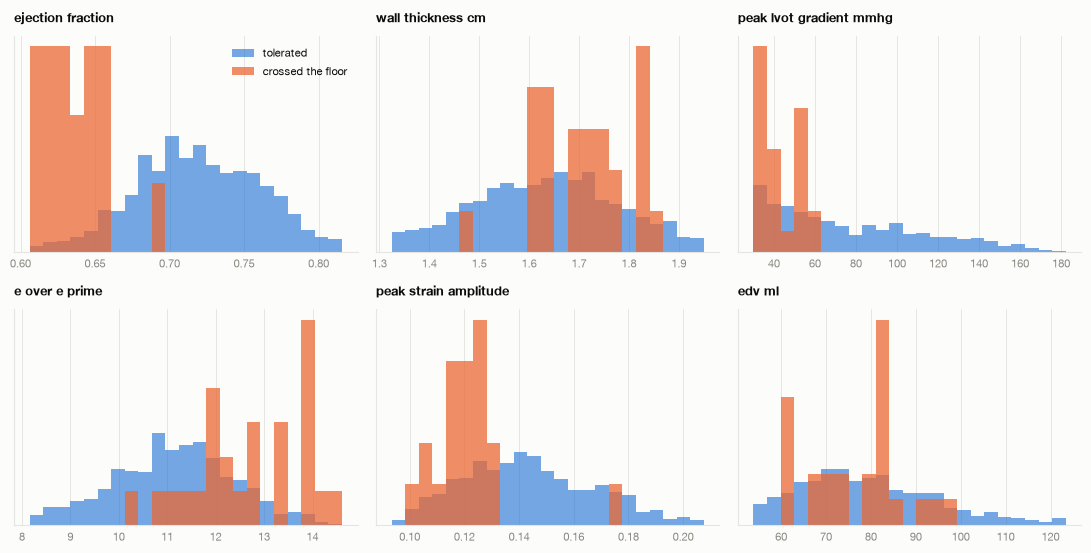

In [3]:
safe = eligible[~eligible["over_responder"]]
crash = eligible[eligible["over_responder"]]
print(f"over-responders at or below the mid dose: {len(crash)} of {len(eligible)} "
      f"({100 * len(crash) / len(eligible):.2f}%)")

candidates = ["ejection_fraction", "wall_thickness_cm", "peak_lvot_gradient_mmhg",
              "e_over_e_prime", "peak_strain_amplitude", "edv_ml"]
figure, axes = plt.subplots(2, 3, figsize=(11, 5.6))
for ax, name in zip(axes.ravel(), candidates):
    bins = np.linspace(eligible[name].quantile(0.01), eligible[name].quantile(0.99), 24)
    ax.hist(safe[name], bins=bins, density=True, color=style.SERIES[0], alpha=0.65,
            label="tolerated", linewidth=0)
    if len(crash):
        ax.hist(crash[name], bins=bins, density=True, color=style.SERIES[1], alpha=0.75,
                label="crossed the floor", linewidth=0)
    ax.set_title(name.replace("_", " "), fontsize=9)
    ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## What actually differs

The separation is in the *hidden* columns, which a clinic cannot see. This is the whole
argument in one table.

In [4]:
hidden = [c for c in eligible.columns if c.startswith("true_")]
if len(crash):
    contrast = pd.DataFrame({
        "tolerated": safe[hidden].median(),
        "crossed the floor": crash[hidden].median(),
    })
    contrast["ratio"] = contrast["crossed the floor"] / contrast["tolerated"]
    display(contrast.round(3).sort_values("ratio"))
else:
    print("no over-responders in this cohort; rerun with a larger n_base")

,tolerated,crossed the floor,ratio
true_clearance_l_per_h,0.613,0.271,0.442
true_phi_baseline,0.479,0.320,0.667
true_phi_effective,0.479,0.320,0.667
true_atp_per_head_per_beat,3.873,2.879,0.743
true_peak_attached_fraction,0.481,0.394,0.818
true_ca50_ref_um,0.600,0.695,1.159
true_b_pas,12.708,17.106,1.346
true_contractile_reserve,0.366,0.508,1.388
true_a_pas_kpa,2.867,4.547,1.586
true_concentration_ng_per_ml,0.000,0.000,NaN
